***Image Analysis with plots***

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.chdir(r"C:\Users\hswt122arb\Desktop\MLplantcv")
print(os.listdir())



['Day32_T1_A.JPG', 'Day32_T1_B.JPG', 'Day32_T1_C.JPG', 'Day32_T1_D.JPG', 'Day32_T2_A.JPG', 'Day32_T2_B.JPG', 'Day32_T2_C.JPG', 'Day32_T2_D.JPG', 'Day32_T3_A.JPG', 'Day32_T3_B.JPG', 'Day32_T3_C.JPG', 'Day32_T3_D.JPG', 'Day32_T4_A.JPG', 'Day32_T4_B.JPG', 'Day32_T4_C.JPG', 'Day32_T4_D.JPG', 'Day35_T1_A.JPG', 'Day35_T1_B.JPG', 'Day35_T1_C.JPG', 'Day35_T1_D.JPG', 'Day35_T2_A.JPG', 'Day35_T2_B.JPG', 'Day35_T2_C.JPG', 'Day35_T2_D.JPG', 'Day35_T3_A.JPG', 'Day35_T3_B.JPG', 'Day35_T3_C.JPG', 'Day35_T3_D.JPG', 'Day35_T4_A.JPG', 'Day35_T4_B.JPG', 'Day35_T4_C.JPG', 'Day35_T4_D.JPG', 'plant_results.csv']


In [2]:
# ---- SCALE ----
PIXELS_per_cm =  1470/ 8

cm_per_pixel = 1 / PIXELS_per_cm
cm2_per_pixel = cm_per_pixel ** 2

print("PIXELS_per_cm =", PIXELS_per_cm)
print("cm_per_pixel =", cm_per_pixel)
print("cm2_per_pixel =", cm2_per_pixel)

# ---- SEGMENTATION SETTINGS ----
LOWER_GREEN = np.array([35, 60, 40])
UPPER_GREEN = np.array([85, 255, 180])

MIN_AREA = 80


PIXELS_per_cm = 183.75
cm_per_pixel = 0.005442176870748299
cm2_per_pixel = 2.9617289092507746e-05


In [3]:
def process_image(filename, show=True):
    img_bgr = cv2.imread(filename)

    if img_bgr is None:
        print(f"Could not read {filename}")
        return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # Green mask
    mask = cv2.inRange(hsv, LOWER_GREEN, UPPER_GREEN)

    # Light cleaning
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    clean_mask = np.zeros_like(mask)

    valid_contours = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > MIN_AREA:
            valid_contours.append(cnt)

    if len(valid_contours) == 0:
        print(f"No plant detected in {filename}")
        return None

    # Draw ALL valid contours, not just the largest one
    cv2.drawContours(clean_mask, valid_contours, -1, 255, -1)

    # Measurements in pixels
    leaf_pixels = np.sum(clean_mask > 0)

    ys, xs = np.where(clean_mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        print(f"No valid plant pixels found in {filename}")
        return None

    plant_diameter_pixels = max(xs.max() - xs.min(), ys.max() - ys.min())

    # Color index (ExG)
    pixels = img_rgb[clean_mask > 0]
    r = np.mean(pixels[:, 0])
    g = np.mean(pixels[:, 1])
    b = np.mean(pixels[:, 2])
    exg = 2 * g - r - b

    # Convert to real units
    leaf_area_cm2 = leaf_pixels * cm2_per_pixel
    plant_diameter_cm = plant_diameter_pixels * cm_per_pixel

    # Overlay
    overlay = img_rgb.copy()
    green = np.zeros_like(img_rgb)
    green[:] = [0, 255, 0]

    overlay[clean_mask > 0] = (
        0.6 * overlay[clean_mask > 0] + 0.4 * green[clean_mask > 0]
    ).astype(np.uint8)

    if show:
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        ax[0].imshow(img_rgb)
        ax[0].set_title("Original")
        ax[0].axis("off")

        ax[1].imshow(clean_mask, cmap="gray")
        ax[1].set_title("Mask")
        ax[1].axis("off")

        ax[2].imshow(overlay)
        ax[2].set_title("Detected Leaves")
        ax[2].axis("off")

        plt.tight_layout()
        plt.show()

        print("leaf_pixels =", leaf_pixels)
        print("plant_diameter_pixels =", plant_diameter_pixels)
        print("Leaf_Area_cm2 =", round(leaf_area_cm2, 3))
        print("Plant_Diameter_cm =", round(plant_diameter_cm, 3))
        print("Color_Index =", round(exg, 3))

    return {
        "Image": filename,
        "Leaf_Area_cm2": round(leaf_area_cm2, 3),
        "Plant_Diameter_cm": round(plant_diameter_cm, 3),
        "Color_Index": round(exg, 3)
    }


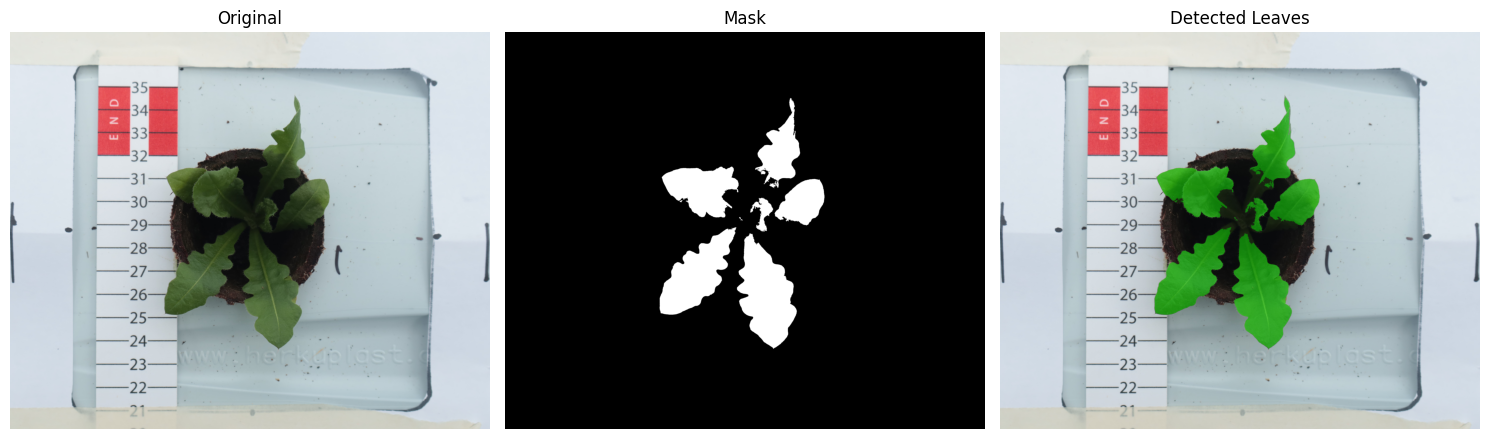

leaf_pixels = 1140489
plant_diameter_pixels = 2298
Leaf_Area_cm2 = 33.778
Plant_Diameter_cm = 12.506
Color_Index = 63.051
{'Image': 'Day35_T1_A.JPG', 'Leaf_Area_cm2': np.float64(33.778), 'Plant_Diameter_cm': np.float64(12.506), 'Color_Index': np.float64(63.051)}


In [5]:
result = process_image("Day35_T1_A.JPG", show=True)
print(result)
    

In [6]:
results = []

for file in os.listdir():
    if file.upper().endswith(".JPG"):
        res = process_image(file, show=False)
        if res is not None:
            results.append(res)

df = pd.DataFrame(results)
df

,Image,Leaf_Area_cm2,Plant_Diameter_cm,Color_Index
0,Day32_T1_A.JPG,31.352,12.299,70.335
1,Day32_T1_B.JPG,38.922,11.184,60.277
2,Day32_T1_C.JPG,34.158,10.618,63.696
3,Day32_T1_D.JPG,16.538,11.771,68.055
4,Day32_T2_A.JPG,45.210,14.264,51.651
5,Day32_T2_B.JPG,25.766,11.848,52.194
6,Day32_T2_C.JPG,45.422,13.932,46.596
7,Day32_T2_D.JPG,32.736,12.642,53.331
8,Day32_T3_A.JPG,52.742,18.269,51.626
9,Day32_T3_B.JPG,39.400,12.620,51.998


In [7]:
results = []

for file in os.listdir():
    if file.upper().endswith(".JPG"):
        res = process_image(file, show=False)
        if res is not None:
            results.append(res)

df = pd.DataFrame(results)
df

,Image,Leaf_Area_cm2,Plant_Diameter_cm,Color_Index
0,Day32_T1_A.JPG,31.352,12.299,70.335
1,Day32_T1_B.JPG,38.922,11.184,60.277
2,Day32_T1_C.JPG,34.158,10.618,63.696
3,Day32_T1_D.JPG,16.538,11.771,68.055
4,Day32_T2_A.JPG,45.210,14.264,51.651
5,Day32_T2_B.JPG,25.766,11.848,52.194
6,Day32_T2_C.JPG,45.422,13.932,46.596
7,Day32_T2_D.JPG,32.736,12.642,53.331
8,Day32_T3_A.JPG,52.742,18.269,51.626
9,Day32_T3_B.JPG,39.400,12.620,51.998


In [8]:
# Make a copy
plot_df = df.copy()

# Extract DAS from names like Day02_T1_A.JPG
plot_df["DAS"] = plot_df["Image"].str.extract(r"Day(\d+)", expand=False).astype(int)

# Create plant ID from table + plant letter/number
# Example: Day02_T1_A.JPG -> T1_A
plot_df["Plant_ID"] = plot_df["Image"].str.extract(r"Day\d+_(T\d+_[A-Za-z0-9]+)", expand=False)

# Sort properly
plot_df = plot_df.sort_values(["Plant_ID", "DAS"])

plot_df.head()

,Image,Leaf_Area_cm2,Plant_Diameter_cm,Color_Index,DAS,Plant_ID
0,Day32_T1_A.JPG,31.352,12.299,70.335,32,T1_A
16,Day35_T1_A.JPG,33.778,12.506,63.051,35,T1_A
1,Day32_T1_B.JPG,38.922,11.184,60.277,32,T1_B
17,Day35_T1_B.JPG,43.483,11.080,54.062,35,T1_B
2,Day32_T1_C.JPG,34.158,10.618,63.696,32,T1_C


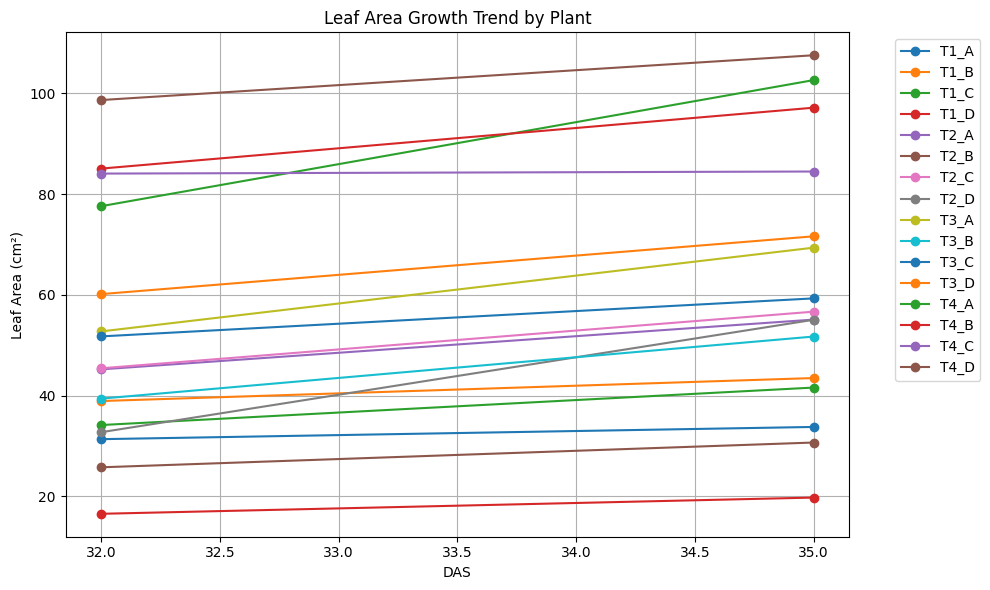

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for plant_id, grp in plot_df.groupby("Plant_ID"):
    plt.plot(grp["DAS"], grp["Leaf_Area_cm2"], marker="o", label=plant_id)

plt.xlabel("DAS")
plt.ylabel("Leaf Area (cm²)")
plt.title("Leaf Area Growth Trend by Plant")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

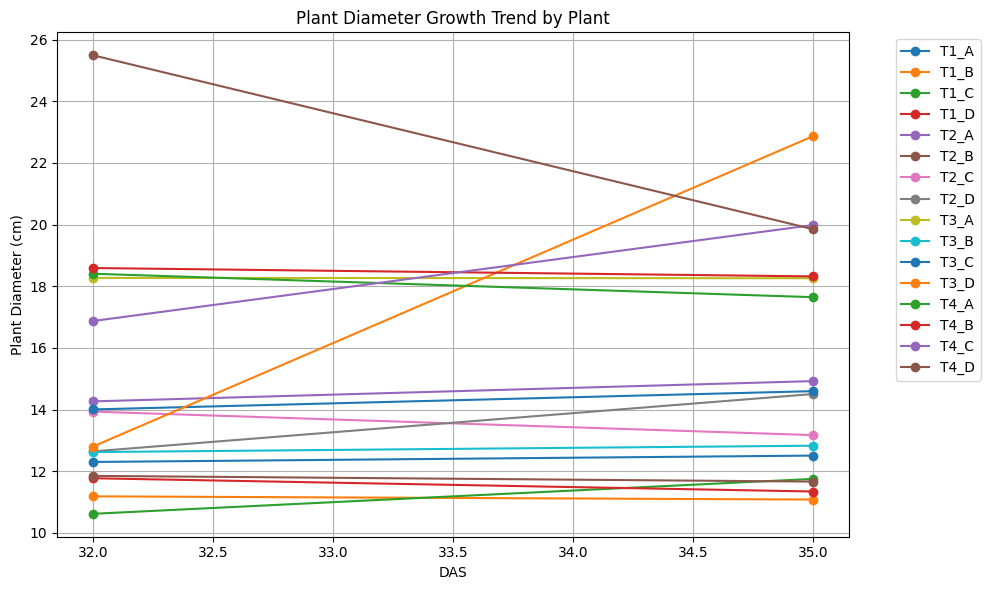

In [10]:
plt.figure(figsize=(10, 6))

for plant_id, grp in plot_df.groupby("Plant_ID"):
    plt.plot(grp["DAS"], grp["Plant_Diameter_cm"], marker="o", label=plant_id)

plt.xlabel("DAS")
plt.ylabel("Plant Diameter (cm)")
plt.title("Plant Diameter Growth Trend by Plant")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
avg_df = plot_df.groupby("DAS", as_index=False)[["Leaf_Area_cm2", "Plant_Diameter_cm"]].mean()

avg_df

,DAS,Leaf_Area_cm2,Plant_Diameter_cm
0,32,51.222125,14.725437
1,35,61.243437,15.329937


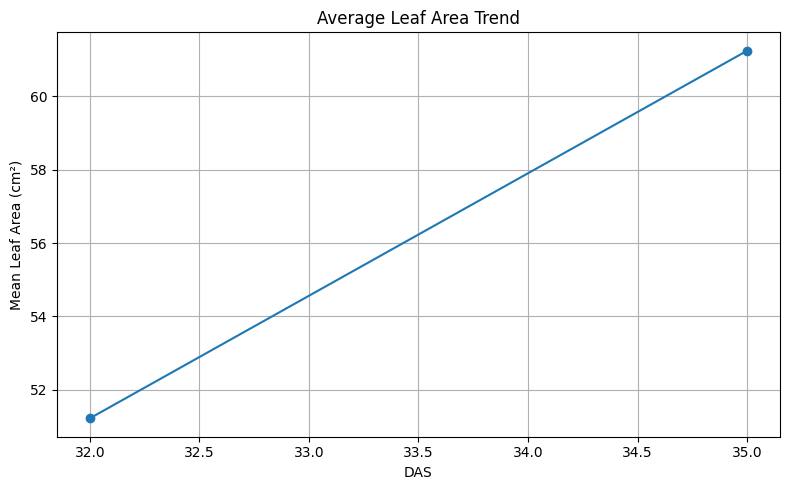

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(avg_df["DAS"], avg_df["Leaf_Area_cm2"], marker="o")
plt.xlabel("DAS")
plt.ylabel("Mean Leaf Area (cm²)")
plt.title("Average Leaf Area Trend")
plt.grid(True)
plt.tight_layout()
plt.show()

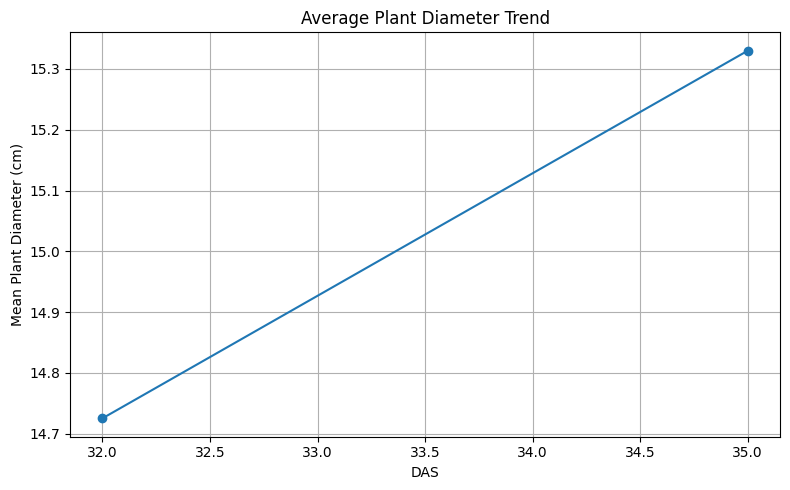

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(avg_df["DAS"], avg_df["Plant_Diameter_cm"], marker="o")
plt.xlabel("DAS")
plt.ylabel("Mean Plant Diameter (cm)")
plt.title("Average Plant Diameter Trend")
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
df.to_csv("plant_results.csv", index=False)
print("Saved ✔")

Saved ✔
